In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 512,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load('runs/newbase/nobehav64_seed0/model_weights.pth'))
model.to(device);
model.eval()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3)

In [3]:
feature_maps = []
feature_vecs = []
pred_resps = []
readout_vecs = []

for key in data_keys:
    single_maps = []
    single_vecs = []
    single_resps = []

    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        single_resps.append(pred.detach().cpu())
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)
        single_vecs.append(feature_vec.detach().cpu())
        
    feature_maps.append(torch.cat(single_maps))
    feature_vecs.append(torch.cat(single_vecs))
    pred_resps.append(torch.cat(single_resps))
    readout_vecs.append(model.readout[key]._features.detach().cpu())

In [4]:
bias = model.readout[data_keys[0]].bias.detach().cpu()
pred = torch.nn.functional.elu((feature_vecs[0].squeeze(-1) * readout_vecs[0].view(1, 64, -1)).sum(1) + bias) + 1
pred, pred_resps[0]

(tensor([[0.1900, 0.2555, 0.1232,  ..., 0.4209, 0.1844, 0.1811],
         [0.1258, 0.0758, 0.1085,  ..., 0.0945, 0.2744, 0.0435],
         [0.2634, 0.2971, 0.1508,  ..., 0.5902, 0.5985, 1.6462],
         ...,
         [0.1754, 0.3569, 0.3845,  ..., 0.4106, 0.1932, 0.1190],
         [0.2894, 0.2850, 0.3913,  ..., 0.5582, 0.2774, 0.1250],
         [0.3379, 0.5088, 0.4094,  ..., 0.1814, 0.6616, 0.2184]]),
 tensor([[0.1900, 0.2555, 0.1232,  ..., 0.4209, 0.1844, 0.1811],
         [0.1258, 0.0758, 0.1085,  ..., 0.0945, 0.2744, 0.0435],
         [0.2634, 0.2971, 0.1508,  ..., 0.5902, 0.5985, 1.6462],
         ...,
         [0.1754, 0.3569, 0.3845,  ..., 0.4106, 0.1932, 0.1190],
         [0.2894, 0.2850, 0.3913,  ..., 0.5582, 0.2774, 0.1250],
         [0.3379, 0.5088, 0.4094,  ..., 0.1814, 0.6616, 0.2184]]))

In [5]:
torch.cat([vecs.permute(0, 2, 3, 1).flatten(0, 2) for  vecs in feature_vecs]).shape

torch.Size([27353476, 64])

In [6]:
X = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

# compute cov
mu = X.mean(dim=0, keepdims=True)
Xc = X - mu
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

# get whitening matrix from cov
L = torch.linalg.cholesky(cov)
Winv = L.T
W = Winv.inverse()

# whiten channels
C = feature_vecs[0].squeeze().permute(2, 0, 1)
Cc = C - mu
Cw = Cc @ W

Cwf = Cw.flatten(0, 1)
cov_w = Cwf.T @ Cwf / (Cwf.shape[0] - 1)
print('whitened cov max deviation from identity:', (cov_w - torch.eye(64)).abs().max())

# compute corresponding readout vecs
R = readout_vecs[0].squeeze().T.unsqueeze(2)
Rw = Winv @ R

# compare results

print((Cw @ Rw + mu @ R).squeeze())
print((C @ R).squeeze())

whitened cov max deviation from identity: tensor(1.4428)
tensor([[-1.1575, -1.5698, -0.8308,  ..., -1.2370, -0.7365, -0.5814],
        [-0.8863, -2.1010, -0.7356,  ..., -0.5522, -0.7772, -0.1974],
        [-1.4602, -1.5866, -1.2578,  ..., -0.3216, -0.3040, -0.2590],
        ...,
        [-0.4943, -1.9880, -0.1564,  ..., -0.5192, -0.2120, -1.3359],
        [-0.7835, -0.3859,  0.3939,  ..., -0.7369, -0.3749,  0.4941],
        [-1.2482, -2.6734,  1.1068,  ..., -1.6682, -1.6188, -1.0610]])
tensor([[-1.1575, -1.5698, -0.8308,  ..., -1.2370, -0.7365, -0.5814],
        [-0.8863, -2.1010, -0.7356,  ..., -0.5522, -0.7772, -0.1974],
        [-1.4602, -1.5866, -1.2578,  ..., -0.3216, -0.3040, -0.2590],
        ...,
        [-0.4943, -1.9880, -0.1564,  ..., -0.5192, -0.2120, -1.3359],
        [-0.7835, -0.3859,  0.3939,  ..., -0.7369, -0.3749,  0.4941],
        [-1.2482, -2.6734,  1.1068,  ..., -1.6682, -1.6188, -1.0610]])


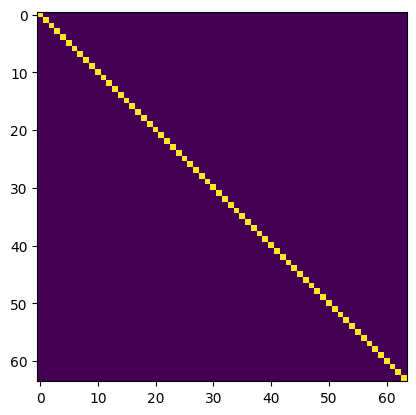

In [6]:
Xw = (X - mu) @ W
plt.imshow(Xw.T @ Xw / (Xw.shape[0] - 1))

In [8]:
R = torch.cat([r.squeeze() for r in readout_vecs], dim=1)
Rw = R.T @ Winv.T

In [10]:
R.shape

torch.Size([64, 54569])

In [8]:
i, j = torch.tril_indices(64, 64, offset=-1)
data = cov_w[i, j]

In [39]:
cov = (Cwf.T @ Cwf) / (Cwf.shape[0] - 1)
std = Cwf.std(dim=0, keepdim=True)
corr = cov / (std.T @ std)

In [43]:
i, j = torch.tril_indices(64, 64, offset=-1)
offdiag = corr[i, j]

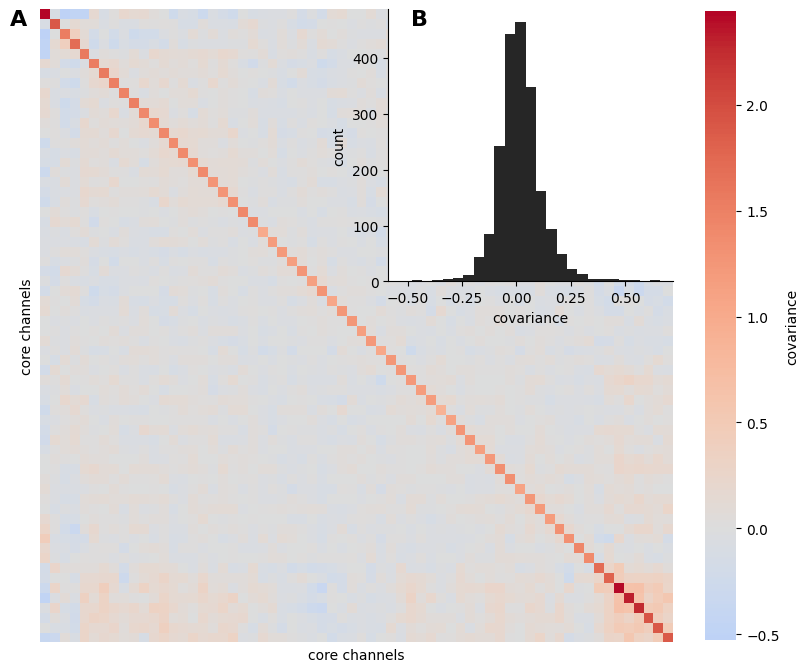

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Assuming corr is already defined (your correlation matrix)

# Create figure with just one plot
fig, ax = plt.subplots(1, 1, figsize=(8, 7.1), constrained_layout=True)

# --- Correlation heatmap ---
data = cov_w
clustermap = sns.clustermap(data)
order = clustermap.dendrogram_row.reordered_ind
plt.close(clustermap.fig)
data = data[order][:, order]

hm = sns.heatmap(
    data,
    ax=ax,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": 0.9},
    xticklabels=False,
    yticklabels=False,
)
ax.set_xlabel("core channels")
ax.set_ylabel("core channels")
hm.figure.axes[-1].set_ylabel("covariance")
ax.text(-0.02, 1, 'A', transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='right')

# --- Inset histogram (top-right overlay) ---
# get lower-triangular correlations (exclude diagonal)
data_np = np.asarray(data)
i, j = np.tril_indices(data_np.shape[0], k=-1)
corr_values = data_np[i, j]

axins = inset_axes(ax, width="45%", height="43%", loc="upper right", borderpad=0)
axins.hist(corr_values, bins=25, color="black", alpha=0.85)
axins.text(0.14, 1, 'B', transform=axins.transAxes,
          fontsize=16, fontweight='bold', va='top', ha='right')
axins.set_xlabel('covariance')
axins.set_ylabel('count')
#axins.set_xticks([-0.2, 0, 0.2, 0.4])
axins.spines['top'].set_visible(False)
axins.spines['right'].set_visible(False)

# Save and show
plt.savefig('plots/results_whitened_vecs.pdf')
plt.show()

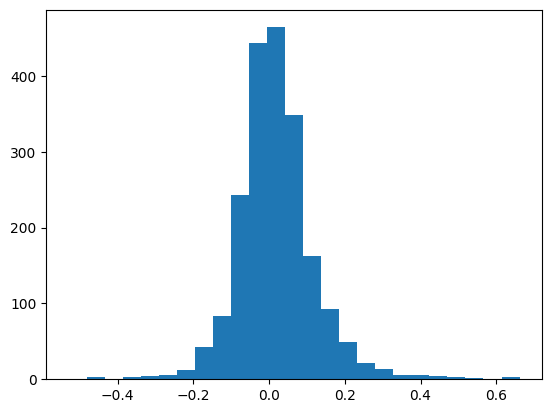

In [10]:
plt.hist(data, bins=25)
plt.show()

In [22]:
from sklearn.neighbors import NearestNeighbors

In [23]:
def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

In [24]:
def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    curve = np.zeros(len(k_range))
    for x, y in zip(x_idcs, y_idcs):
        curve += knn_consistency(knns[x], knns[y], ks=k_range) 
    
    curve /= len(x_idcs)

    return curve

In [25]:
k_range = np.unique(np.geomspace(1, 100, num=10, dtype=int))
curve = get_curve(k_range, [Rw])

/tmp/ipykernel_3234222/1207887741.py:14: RuntimeWarning: invalid value encountered in divide
  curve /= len(x_idcs)


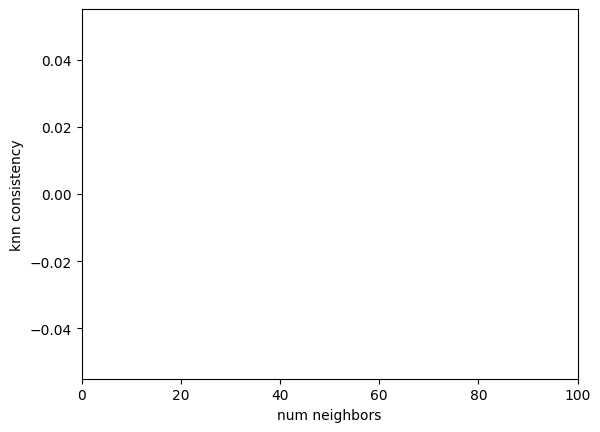

In [26]:
plt.plot(k_range, curve, ls='--', marker='o')

plt.xlabel('num neighbors')
plt.ylabel('knn consistency')
plt.xlim(0, 100)
plt.show()